# Matcha-TTS: A fast TTS architecture with conditional flow matching
---
[Shivam Mehta](https://www.kth.se/profile/smehta), [Ruibo Tu](https://www.kth.se/profile/ruibo), [Jonas Beskow](https://www.kth.se/profile/beskow), [Éva Székely](https://www.kth.se/profile/szekely), and [Gustav Eje Henter](https://people.kth.se/~ghe/)

We introduce Matcha-TTS, a new encoder-decoder architecture for speedy TTS acoustic modelling, trained using optimal-transport conditional flow matching (OT-CFM). This yields an ODE-based decoder capable of high output quality in fewer synthesis steps than models trained using score matching. Careful design choices additionally ensure each synthesis step is fast to run. The method is probabilistic, non-autoregressive, and learns to speak from scratch without external alignments. Compared to strong pre-trained baseline models, the Matcha-TTS system has the smallest memory footprint, rivals the speed of the fastest models on long utterances, and attains the highest mean opinion score in a listening test.

Demo Page: https://shivammehta25.github.io/Matcha-TTS \
Code: https://github.com/shivammehta25/Matcha-TTS




In [ ]:
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [7]:
import datetime as dt
from pathlib import Path

import IPython.display as ipd
import numpy as np
import soundfile as sf
import torch
import random
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from lightning import seed_everything

# Hifigan imports
from matcha.hifigan.config import v1
from matcha.hifigan.denoiser import Denoiser
from matcha.hifigan.env import AttrDict
from matcha.hifigan.models import Generator as HiFiGAN
# Matcha imports
from matcha.models.matcha_tts import MatchaTTS
from matcha.text import sequence_to_text, text_to_sequence
from matcha.utils.model import denormalize
from matcha.utils.utils import get_user_data_dir, intersperse

In [8]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
# This allows for real time code changes being reflected in the notebook, no need to restart the kernel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Filepaths

In [10]:
# MATCHA_CHECKPOINT = "logs/train/tsg2_stoc_dur/runs/2024-01-05_12-35-07/checkpoints/last.ckpt"
# MATCHA_CHECKPOINT = "logs/train/lj_stoc/runs/2024-01-12_12-03-19/checkpoints/checkpoint_epoch=3299.ckpt"
MATCHA_CHECKPOINT = "logs/train/joe_stoc_dur/runs/2024-02-20_14-01-53/checkpoints/last.ckpt"
HIFIGAN_CHECKPOINT = get_user_data_dir() / "hifigan_univ_v1"
OUTPUT_FOLDER = "cormac_fm_output2"

## Load Matcha-TTS

In [11]:
def load_model(checkpoint_path):
    model = MatchaTTS.load_from_checkpoint(checkpoint_path, map_location=device)
    model.eval()
    return model
count_params = lambda x: f"{sum(p.numel() for p in x.parameters()):,}"


model = load_model(MATCHA_CHECKPOINT)
print(f"Model loaded! Parameter count: {count_params(model)}")

Model loaded! Parameter count: 18,336,545


## Load HiFi-GAN (Vocoder)

In [12]:
def load_vocoder(checkpoint_path):
    h = AttrDict(v1)
    hifigan = HiFiGAN(h).to(device)
    hifigan.load_state_dict(torch.load(checkpoint_path, map_location=device)['generator'])
    _ = hifigan.eval()
    hifigan.remove_weight_norm()
    return hifigan

vocoder = load_vocoder(HIFIGAN_CHECKPOINT)
denoiser = Denoiser(vocoder, mode='zeros')

Removing weight norm...


### Helper functions to synthesise

In [13]:
import json

@torch.inference_mode()
def process_text(text: str):
    x = torch.tensor(intersperse(text_to_sequence(text, ['english_cleaners2'])[0], 0),dtype=torch.long, device=device)[None]
    x_lengths = torch.tensor([x.shape[-1]],dtype=torch.long, device=device)
    x_phones = sequence_to_text(x.squeeze(0).tolist())
    return {
        'x_orig': text,
        'x': x,
        'x_lengths': x_lengths,
        'x_phones': x_phones
    }


@torch.inference_mode()
def synthesise(text, spks=None):
    text_processed = process_text(text)
    start_t = dt.datetime.now()
    output = model.synthesise(
        text_processed['x'], 
        text_processed['x_lengths'],
        n_timesteps=n_timesteps,
        temperature=temperature,
        spks=spks,
        length_scale=length_scale
    )
    # merge everything to one dict    
    output.update({'start_t': start_t, **text_processed})
    return output

@torch.inference_mode()
def to_waveform(mel, vocoder):
    audio = vocoder(mel).clamp(-1, 1)
    audio = denoiser(audio.squeeze(0), strength=0.00025).cpu().squeeze()
    return audio.cpu().squeeze()
    
def save_to_folder(filename: str, output: dict, folder: str):
    folder = Path(folder)
    folder.mkdir(exist_ok=True, parents=True)
    np.save(folder / f'{filename}', output['mel'].cpu().numpy())
    sf.write(folder / f'{filename}.wav', output['waveform'], 22050, 'PCM_24')
    if "duration_json" in output:
        with open(folder / f'{filename}.json', 'w', encoding='utf-8') as f:
            json.dump(output['duration_json'], f, indent=4, ensure_ascii=False)

def plot_spectrogram(spectrogram):
    fig, ax = plt.subplots(figsize=(12, 3))
    im = ax.imshow(spectrogram.squeeze().cpu().numpy(), aspect="auto", origin="lower", interpolation="none")
    plt.colorbar(im, ax=ax)
    plt.xlabel("Frames")
    plt.ylabel("Channels")
    plt.title("Synthesised Mel-Spectrogram")
    plt.show()

## Setup text to synthesise

In [14]:
texts = [
    "; What I used to do this is crazy I was destroying my skin, ; in the mornings because I used to hate sweating, because that would make my skin oily; and that will block my pores and that will give me more spots.",
    "; What I used to do this is crazy I was destroying my skin, ; in the mornings because I used to hate sweating, because that would make my skin oily; and that will block my pores and that will give me more spots.",
    "; What I used to do this is crazy I was destroying my skin, ; in the mornings because I used to hate sweating, because that would make my skin oily; and that will block my pores and that will give me more spots.",
    "; So I remember I ran as fast as I could I tried to get out; , between a; , The people as quickly as I could because I was like oh my god my stomach is just like, Killing me.",
    "; So I remember I ran as fast as I could I tried to get out; , between a; , The people as quickly as I could because I was like oh my god my stomach is just like, Killing me.",
    "; So I remember I ran as fast as I could I tried to get out; , between a; , The people as quickly as I could because I was like oh my god my stomach is just like, Killing me.",
    "; So I remember I ran as fast as I could I tried to get out; , between a; , The people as quickly as I could because I was like oh my god my stomach is just like, Killing me.",
    "that's only another story; Same story again same family This is the same family I'm telling you; Their house is haunted 100% haunted okay?; because they're.",
    "that's only another story; Same story again same family This is the same family I'm telling you; Their house is haunted 100% haunted okay?; because they're.",
    "that's only another story; Same story again same family This is the same family I'm telling you; Their house is haunted 100% haunted okay?; because they're.",
    "that's only another story; Same story again same family This is the same family I'm telling you; Their house is haunted 100% haunted okay?; because they're.",
    
    # "Optionally, the ONNIX exporter accepts vocoder-name and vocoder-checkpoint arguments, This enables you to embed the vocoder in the exported graph and generate waveforms in a single run, (similar to end-to-end TTS systems).",
]

In [15]:
texts = [
    "If, you know, it works as well as we would expect, it would change our, like, understanding of the world.",
    "If, you know, it works as well as we would expect, it would change our, like, understanding of the world.",
    "; If, you know, it works as well as we would expect, it would change our, like, understanding of the world.",
    "; If, you know, it works as well as we would expect, it would change our, like, understanding of the world.",
    "We've, uh, been working on this project where, you know, I think is interesting, just, you know, really cool.",
    "We've, uh, been working on this project where, you know, I think is interesting, just, you know, really cool.",
    "; We've, uh, been working on this project where, you know, I think is interesting, just, you know, really cool.",
    "; We've, uh, been working on this project where, you know, I think is interesting, just, you know, really cool.",
    "I heard about this thing called, uhm, big wave surfing, where these guys tackle waves of over 20 metres, just insane.",
    "I heard about this thing called, uhm, big wave surfing, where these guys tackle waves of over 20 metres, just insane.",
    "; I heard about this thing called, uhm, big wave surfing, where these guys tackle waves of over 20 metres, just insane.",
    "; I heard about this thing called, uhm, big wave surfing, where these guys tackle waves of over 20 metres, just insane.",
    "I need to go to this, uhm, mandatory work seminar that I really don't want to attend.",
    "I need to go to this, uhm, mandatory work seminar that I really don't want to attend.",
    "; I need to go to this, uhm, mandatory work seminar that I really don't want to attend.",
    "; I need to go to this, uhm, mandatory work seminar that I really don't want to attend.",
    
]

In [16]:
texts = [
    "So, yesterday I went to the zoo, and, you know, it was such an incredible experience ; I mean, like, absolutely breathtaking!",
    "I wasn't quite sure what to expect, but, you know, it turned out to be really, really fun ; like, surprisingly enjoyable.",
    "Oh, I saw so many amazing animals ; lions, tigers, elephants, you name it ; it was like a wildlife paradise!",
    "At first, I thought it might be crowded, but, fortunately, it wasn't too bad ; I guess I got lucky.",
    "You know, I'm not usually a fan of large crowds, but somehow, I managed to enjoy myself ; it was quite the adventure.",
    "So, when I got there, the first thing I did was head straight to the monkey exhibit ; those little guys are just so fascinating, you know?",
    "Ah, I'm absolutely fascinated by monkeys ; they're so lively and entertaining to watch ; I could spend hours just observing them.",
    "I spent quite a bit of time there, just admiring their playful antics and interactions with each other.",
    "But eventually, I decided to tear myself away and, like, explore the rest of the zoo ; there was just so much more to see!",
    "Oh, I stumbled upon the giraffe enclosure next ; those majestic creatures are truly a sight to behold, don't you think?",
    "I took a ton of pictures of them, but, none of them really did justice to their beauty ; they're just so graceful and magnificent.",
    "You know, I'm not exactly the best photographer, but I tried my best to capture their elegance and grandeur.",
    "So, after spending some time with the giraffes, I decided to take a little break and, like, grab a snack.",
    "Ah, I'm a bit of a sucker for zoo food ; it may not be the healthiest, but, it's definitely delicious ; I just couldn't resist.",
    "I indulged in some popcorn and, a soda, and just, you know, sat down for a while, soaking in the vibrant atmosphere around me.",
    "But soon enough, I felt re-energized and ready to, like, embark on the next leg of my zoo adventure ; there was still so much to explore!",
    "Oh, I stumbled upon the reptile house next ; now that, that was an experience, let me tell you!",
    "I have to admit, I'm not exactly fond of snakes, but, I braved my fears and ventured in anyway ; it was quite the adrenaline rush.",
    "You know, I'm not entirely sure why I did that to myself, but, it definitely made for an interesting experience, to say the least.",
    "So, I cautiously made my way through the exhibit, trying not to, like, jump at every sudden movement or slithering motion ; it was quite the challenge.",
    "Ah, I'm proud of myself for confronting my fears head-on, but, you know, I don't think I'll be rushing back to the reptile house anytime soon ; once was probably enough for me.",
    "After that rather nerve-wracking experience, I felt the need for something a little more uplifting, so I, like, headed straight for the penguin exhibit.",
    "I absolutely adore penguins ; they're just so adorable and, comical, especially when they waddle around on land ; it's simply delightful to watch.",
    "I spent a good amount of time there, just enjoying their playful antics and quirky personalities ; they never fail to bring a smile to my face.",
    "But eventually, I tore myself away and, like, continued on with my zoo adventure ; there were still so many more exhibits to explore!",
    "Oh, I stumbled upon the big cat area next ; now that, that was an exhilarating experience, let me tell you!",
    "I have to admit, I was both excited and a little nervous to see the lions and tigers up close ; they're such majestic and powerful creatures.",
    "I kept a safe distance, of course, but, just being in their presence filled me with a sense of awe and wonder.",
    "But, as the day started to draw to a close, I realized that my time at the zoo was coming to an end ; it was bittersweet, to say the least.",
    "Oh, I hadn't realized how quickly the hours had flown by ; I guess I was just having too much fun!",
    "So, I reluctantly made my way towards the exit, but not before promising myself that I'd, like, come back again soon ; there was still so much more to see and explore!",
    "I felt a profound sense of gratitude for the incredible experience I'd had at the zoo ; it was truly unforgettable, and I couldn't wait to, like, do it all over again!",
]

In [17]:
texts = [" I will have to, uh, make sure to charge my camera battery ; I don't want it dying on me while we're out.",
 " I heard there's a, a sort of farmers' market on the weekends ; so we might, uh, we might swing by that, uh, just to see, you know?",
 " I'm not really, uh, sure what to expect from this shopping center ; but I've heard good things from friends who've been there already.",
 ' I will have to, uh, remind my sister to, uh, wear comfortable shoes ; last time she insisted on heels and regretted it halfway through the day.',
 " I've been saving up for a, uh, new phone case, so I will, uh, definitely check out the, uh, tech accessory store.",
 " my family, we like to, uh, make a day of it ; you know, shopping together, eating together, it's, uh, it's nice.",
 "; , And I've got to, uh, look for some new headphones ; mine just broke and, uh, I can't go to the gym without them, you know?",
 "; , My dad, he wants to check out the, uh, the hardware store ; he's always looking for tools and, uh, stuff like that.",
 'But, as the day started to draw to a close, I realized that my time at the zoo was coming to an end ; it was bittersweet, to say the least.',
 'So, after spending some time with the giraffes, I decided to take a little break and, like, grab a snack.',
 'But eventually, I tore myself away and, like, continued on with my zoo adventure ; there were still so many more exhibits to explore!',
 "Oh, I hadn't realized how quickly the hours had flown by ; I guess I was just having too much fun!",
 "Ah, I'm a bit of a sucker for zoo food ; it may not be the healthiest, but, it's definitely delicious ; I just couldn't resist.",
 " I will probably, uh, get distracted by all the, uh, sales and promotions ; I'm a sucker for a good deal.",
 "; , Uhm, my cousin, the one who's, uh, into photography ; he's, uh, he's going to look for a new, uh, camera lens at the, the camera store.",
 "; And, uh, there's this, uh, arcade area that I'm kinda, uh, interested in ; I used to love playing those games when I was younger.",
 "You know, I'm not usually a fan of large crowds, but somehow, I managed to enjoy myself ; it was quite the adventure.",
 "; , And, uh, my mom's been talking about this, uh, new recipe book she wants to get ; so she's on the lookout for it.",
 "Ah, I'm proud of myself for confronting my fears head-on, but, you know, I don't think I'll be rushing back to the reptile house anytime soon ; once was probably enough for me.",
 "; I think my dad's, uh, really excited about the, uh, electronics section ; he's been talking about upgrading his gadgets for a while now.",
 " there's this, uh, chocolate shop that gives out free samples ; and, uh, you know, who can say no to, uh, free chocolate?",
 "; , Uhm, they've got an indoor, uh, mini-golf place ; which could be a, uh, fun way to take a break from all the shopping.",
 '; , So the plan is to, uhm, meet up at, like, the central plaza ; after everyone is done with their, uh, their own shopping and stuff.',
 "; , And, uh, my aunt, she's big on, uhm, organic stuff ; so she's excited about the, the natural skincare shop that's, uh, that's there.",
 'But eventually, I decided to tear myself away and, like, explore the rest of the zoo ; there was just so much more to see!',
 " I will probably, uh, end up carrying most of the shopping bags ; it's just easier for me since I'm used to it.",
 "; , And, uh, my mom's been talking about this, uh, new fitness craze she wants to try ; so she's looking for workout gear.",
 ' I will have to, uh, make sure to bring my reusable shopping bags ; you know, to reduce waste and all that.',
 "; , Uhm, my family, we're not, you know, super outdoorsy ; but there's an outdoor goods store, so maybe we'll, uh, we'll take a look, just in case, you know?",
 'Oh, I saw so many amazing animals ; lions, tigers, elephants, you name it ; it was like a wildlife paradise!',
 ' I will need to, uh, make a list of things I want to buy beforehand ; otherwise, I will end up forgetting.',
 "; They have this, uh, loyalty program thing ; so I'm gonna sign up, you know, to get, uh, points or whatever, which is, uhm, pretty neat.",
 "; My dad, he's, uh, not that into shopping, right? ; But there's an electronics store, so he'll, he'll probably just, uh, hang out there while we, um, do our thing.",
 " I will probably, uh, take a lot of photos while we're there ; you know, just to capture the memories of our family outing.",
 "; So, we were thinking of going to, uh, that new shopping center, you know, the one that just opened up last month ; and I'm actually, I'm kind of excited about it.",
 'I spent quite a bit of time there, just admiring their playful antics and interactions with each other.',
 '; , And, uh, I might, uh, grab a snack from one of those, uh, food kiosks ; you know, just to keep my energy up while we shop.',
 " I'm kind of excited to try the, the virtual reality experience ; I've never done that before, and, uh, it looks, uh, looks really cool.",
 "; My brother's, uh, he's looking forward to the, the gaming lounge ; they have, like, tournaments and stuff, which is, uhm, pretty cool, I think.",
 "; The kids, they have this, uhm, face painting thing ; so my niece, she's gonna love that, she's, uh, always asking for it.",
 " parking is, uh, it's free for the first two hours, which is, uh, nice ; but I'm sure we'll, we'll be there longer than that, so, uh, we'll see how it goes.",
 " I'm curious about the, the bookstore's cafe ; I've heard they make a, a mean latte, and, uh, you know, I love my coffee.",
 'I spent a good amount of time there, just enjoying their playful antics and quirky personalities ; they never fail to bring a smile to my face.',
 "; , I'm not much for clothes shopping, but, uh, I do need some new jeans ; so, uh, I will be on the lookout for a good, uh, denim place.",
 "; , And, uh, my sister's been talking about this, uh, new fashion trend she wants to try ; so she's looking for specific clothing items.",
 "; I think my brother's, uh, planning to splurge on some, uh, collector's items ; there's a store that sells rare memorabilia that he's into.",
 'I indulged in some popcorn and, a soda, and just, you know, sat down for a while, soaking in the vibrant atmosphere around me.',
 "; Well, I heard, uh, there's supposed to be some sort of event happening ; a, a raffle, or, uh, giveaway? I'm not totally sure but it, it sounds, uh, sounds fun.",
 "; , And, uh, my dad's been talking about this, uh, new barbecue grill he wants to get ; so I'm sure we'll end up at the home improvement store.",
 "; , And, uh, my mom mentioned something about a sale at, uh, her favorite clothing store ; so I bet we'll, we'll end up there for, like, I don't know, an hour, or something.",
 "; , Oh, and, uh, my sister's been talking about redecorating her room ; so she's looking for new bedding and decor.",
 " there's a, a pet store that, uh, lets you, you know, play with the puppies ; and, uh, my little brother, he's, he's definitely looking forward to that.",
 "; , Oh, and, uh, my sister's been talking about this, uh, new restaurant she wants to try ; so we might end up eating there.",
 "; , Oh, and, uh, my cousin, she's been talking about this, uh, new diet she's trying out ; so she's interested in checking out the health food store.",
 "; I'm hoping to, uh, find a nice gift for my mom's birthday ; there's a, uh, specialty shop that sells handmade items, so that might be perfect.",
 "; , And, uh, my little sister, she's all about, uh, the trendy fashion ; so we'll probably, you know, end up browsing those stores longer than expected.",
 "I felt a profound sense of gratitude for the incredible experience I'd had at the zoo ; it was truly unforgettable, and I couldn't wait to, like, do it all over again!",
 "Oh, I stumbled upon the giraffe enclosure next ; those majestic creatures are truly a sight to behold, don't you think?",
 'So, I cautiously made my way through the exhibit, trying not to, like, jump at every sudden movement or slithering motion ; it was quite the challenge.',
 "; , And, uh, the shopping center, it's got, like, this, uh, huge LED screen ; they show sports and, uh, movies on it, which is, uhm, pretty cool.",
 "; , And, uh, my dad's been talking about this, uh, new recipe he wants to try out for dinner ; so he's looking for ingredients.",
 "; , And, uh, my aunt's been raving about this, uh, new skincare brand ; so she's eager to see if the store carries it.",
 "I took a ton of pictures of them, but, none of them really did justice to their beauty ; they're just so graceful and magnificent.",
 'After that rather nerve-wracking experience, I felt the need for something a little more uplifting, so I, like, headed straight for the penguin exhibit.',
 "; , My grandma, she's always, uh, asking for new kitchen gadgets ; so we'll probably swing by the, uh, culinary store for her.",
 "; Uh, my sister, yeah, she's already, like, made a list of all the stores she wants to hit ; and she's, um, she's determined to find those, those boots she saw online, you know?",
 " I'm just hoping I can, you know, find some good deals ; maybe on, uh, clothes or, uhm, shoes? I, I could use some new sneakers, honestly.",
 "; , Uhm, I need to, uh, remember to, uh, pick up a gift for my friend's, uh, birthday ; so I will be, you know, on the lookout for something special.",
 " I'm kinda hoping we can find a good, uh, spot to sit and relax ; you know, when, uh, when our feet start hurting from all the walking around.",
 '; I will have to, uh, remember to charge my phone before we go ; last time it died on me while we were shopping, which was, uh, inconvenient.',
 "; , Oh, and, uh, I heard there's a, a rooftop garden with a nice view ; so we might take a break up there and enjoy the scenery.",
 "; , Oh, and, uh, my dad's been wanting to upgrade our, uh, home entertainment system ; so he's looking for a new TV.",
 "; And, uh, there's supposed to be this, this art exhibit ; in the, uhm, the central atrium, so that'll be, uh, that'll be something to see.",
 " I will probably, you know, look for some new books ; because they've got that, that big bookstore, and, uh, I could spend, like, hours in there, honestly.",
 "; , Oh, and, uh, my sister wants to try out this, uh, new makeup trend she saw online ; so she's looking for specific products.",
 "I have to admit, I was both excited and a little nervous to see the lions and tigers up close ; they're such majestic and powerful creatures.",
 "Ah, I'm absolutely fascinated by monkeys ; they're so lively and entertaining to watch ; I could spend hours just observing them.",
 "; , And, uh, I've heard there's a, a live music performance happening later in the evening ; so we might stick around for that if we're not too tired.",
 "; , Uh, last time we went shopping as a family, it was, uhm, quite the, the adventure ; so, uh, I'm expecting, you know, more of the same today.",
 " I will probably, uh, forget where we parked the car ; I'm terrible with remembering those things.",
 "At first, I thought it might be crowded, but, fortunately, it wasn't too bad ; I guess I got lucky.",
 " I'm thinking of, uh, treating myself to a, a massage at the, uh, spa center ; they have some pretty good deals going on right now.",
 "; , So, uh, yeah, after shopping we're, um, planning to grab dinner ; maybe try out that new, that new Italian place? I've heard, uhm, good things about it.",
 'So, yesterday I went to the zoo, and, you know, it was such an incredible experience ; I mean, like, absolutely breathtaking!',
 'So, when I got there, the first thing I did was head straight to the monkey exhibit ; those little guys are just so fascinating, you know?',
 "You know, I'm not exactly the best photographer, but I tried my best to capture their elegance and grandeur.",
 " I will need to, uh, check the store directory when we get there ; I'm not familiar with the layout of the shopping center.",
 "; We're, uh, probably going to start with the, the food court because, uhm, my brother, he gets, uh, he gets real cranky if he doesn't eat ; and there's supposed to be a, a new sushi place.",
 "; My family, they tend to, uh, split up and, uh, meet back at a certain time ; so we're, uh, probably gonna do that, you know?",
 "; And, uh, there's a, a bookstore signing event ; some author my brother likes, so, uh, we'll probably, you know, check that out.",
 "; , Uhm, the weather's supposed to be good, so we'll, uh, probably take a break outside ; they've got benches and, uh, fountains and stuff.",
 "I wasn't quite sure what to expect, but, you know, it turned out to be really, really fun ; like, surprisingly enjoyable.",
 " I'm not sure if I mentioned this, but, uh, my aunt, she's got this, uh, thing about, uh, finding unique home decor pieces ; so we might, you know, spend a bit of time there.",
 ' the plan is to, uh, get there early, because, you know, parking can be crazy, and, uh, my dad, he, uh, he hates looking for parking spots for too long.',
 " I've been meaning to, uh, buy some new workout gear ; so I will definitely be browsing the, uh, sports apparel stores.",
 " I think my brother's, uh, interested in checking out the, uh, car accessories store ; he's been talking about upgrading his car stereo.",
 'Oh, I stumbled upon the reptile house next ; now that, that was an experience, let me tell you!',
 "; Oh, and, uh, my mom, she wants to check out the new, what's it, the home goods store ; because she's, uh, redecorating the living room, or something like that.",
 " my mom's been talking about this, this scarf she saw online ; and, uh, if we find the store, she's, uh, she's definitely buying it.",
 "You know, I'm not entirely sure why I did that to myself, but, it definitely made for an interesting experience, to say the least."]

### Hyperparameters

In [18]:
## Number of ODE Solver steps
n_timesteps = 10

## Changes to the speaking rate
length_scale=1.0

## Sampling temperature
temperature = 0.667

In [ ]:
from math import ceil


def save_phoneme_durations(output):
    durations = output['attn'].squeeze().sum(1)
    phones = output['x_phones'][1::2]
    prev = durations[0]
    merged_durations = []
    # Convolve with stride 2
    for i in range(1, len(durations), 2):
        if i == len(durations) - 2:
            # if it is last take full value
            next_half = durations[i+1]
        else:
            next_half = ceil(durations[i+1] /2)

        curr = prev + durations[i] + next_half
        prev = durations[i+1] - next_half
        # print(durations[i-1:i+2], curr, next_half, prev)
        merged_durations.append(curr)

    assert len(phones) == len(merged_durations)
    assert len(merged_durations) == (len(durations) - 1) // 2


    merged_durations = torch.cumsum(torch.tensor(merged_durations), 0, dtype=torch.long)
    start = torch.tensor(0)
    duration_json = []
    for i, duration in enumerate(merged_durations):
        duration_json.append({
            phones[i]: {
                "starttime": start.item(),
                "endtime": duration.item(),
                "duration": duration.item() - start.item()
            }
        })
        start = duration
    assert list(duration_json[-1].values())[0]['endtime'] == output['decoder_outputs'].shape[-1], f"{list(duration_json[-1].values())[0]['endtime'],  output['decoder_outputs'].shape[-1]}"
    return duration_json

## Synthesis

In [ ]:
OUTPUT_FOLDER_TEMP = "joe_fm_output_{}"
for name in range(6):
    OUTPUT_FOLDER = OUTPUT_FOLDER_TEMP.format(name)
    print(OUTPUT_FOLDER)
    outputs, rtfs = [], []
    rtfs_w = []
    for i, text in enumerate(tqdm(texts)):
        seed_everything(random.randint(1, 10000))
        output = synthesise(text) #, torch.tensor([15], device=device, dtype=torch.long).unsqueeze(0))
        output['waveform'] = to_waveform(output['mel'], vocoder)
        output['duration_json'] = save_phoneme_durations(output)
        # Compute Real Time Factor (RTF) with HiFi-GAN
        t = (dt.datetime.now() - output['start_t']).total_seconds()
        rtf_w = t * 22050 / (output['waveform'].shape[-1])
    
        ## Pretty print
        print(f"{'*' * 53}")
        print(f"Input text - {i}")
        print(f"{'-' * 53}")
        print(output['x_orig'])
        print(f"{'*' * 53}")
        print(f"Phonetised text - {i}")
        print(f"{'-' * 53}")
        print(output['x_phones'])
        print(f"{'*' * 53}")
        print(f"RTF:\t\t{output['rtf']:.6f}")
        print(f"RTF Waveform:\t{rtf_w:.6f}")
        rtfs.append(output['rtf'])
        rtfs_w.append(rtf_w)
    
        ## Display the synthesised waveform
        # plot_spectrogram(output['mel'])
        # ipd.display(ipd.Audio(output['waveform'], rate=22050))
    
        ## Save the generated waveform
        save_to_folder(i, output, OUTPUT_FOLDER)
    
    print(f"Number of ODE steps: {n_timesteps}")
    print(f"Mean RTF:\t\t\t\t{np.mean(rtfs):.6f} ± {np.std(rtfs):.6f}")
    print(f"Mean RTF Waveform (incl. vocoder):\t{np.mean(rtfs_w):.6f} ± {np.std(rtfs_w):.6f}")

  0%|          | 0/11 [00:00<?, ?it/s]

Global seed set to 1483


tensor([[[ 1.,  1.,  7.,  5.,  3.,  1.,  5.,  1.,  1.,  1.,  1.,  2.,  2.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  2.,  4.,  3.,  2.,  4.,  3.,  2.,  4.,  1.,  1.,  2.,  2.,
           4.,  1.,  2., 11.,  2.,  5.,  4.,  1.,  1.,  1.,  1.,  1.,  4.,  1.,
           1.,  3.,  1.,  1.,  2.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,
           3.,  4.,  2.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,
           2.,  1.,  2.,  2.,  3.,  4.,  3.,  1.,  3.,  1.,  2.,  4.,  2.,  2.,
           1.,  2.,  2.,  2.,  2.,  1.,  2.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,
           1.,  1.,  3.,  1.,  1.,  1.,  2.,  2.,  3.,  1.,  4.,  3.,  4., 15.,
          25.,  3.,  9., 14.,  5.,  1.,  3.,  1.,  2.,  4.,  1.,  1.,  2.,  1.,
           1.,  3.,  1.,  1.,  3.,  2.,  1.,  3.,  1.,  2.,  1.,  3.,  2.,  3.,
           4.,  3.,  2.,  3.,  1.,  2., 

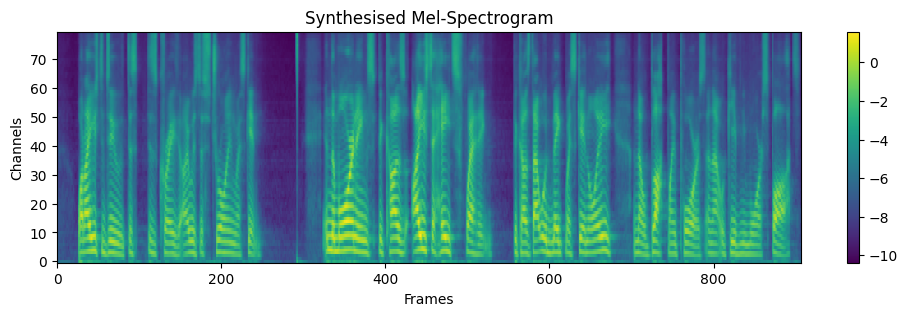

Global seed set to 2243


tensor([[[ 3.,  3.,  1.,  2.,  1.,  1.,  2.,  7.,  2.,  1.,  1.,  1.,  2.,  1.,
           3.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,
           1.,  2.,  2.,  6.,  2.,  3., 13.,  1.,  2.,  2.,  1.,  1.,  3.,  1.,
           5., 15.,  1.,  5.,  1.,  3.,  2.,  1.,  1.,  1.,  1.,  2.,  3.,  1.,
           1.,  2.,  1.,  2.,  3.,  2.,  1.,  2.,  4.,  1.,  2.,  1.,  3.,  4.,
           1.,  3.,  1.,  1.,  1.,  1.,  3.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,
           1.,  1.,  2.,  2.,  3.,  6.,  2.,  2.,  2.,  1.,  2.,  2.,  5.,  2.,
           1.,  2.,  1.,  2.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,
           1.,  2.,  2.,  1.,  1.,  1.,  2.,  3.,  1.,  3.,  7.,  5.,  5., 10.,
          26.,  5.,  7.,  7.,  7.,  2.,  2.,  1.,  1.,  1.,  3.,  1.,  2.,  1.,
           1.,  3.,  1.,  1.,  2.,  1.,  3.,  1.,  3.,  2.,  2.,  1.,  1.,  2.,
           3.,  2.,  3.,  4.,  2.,  1., 

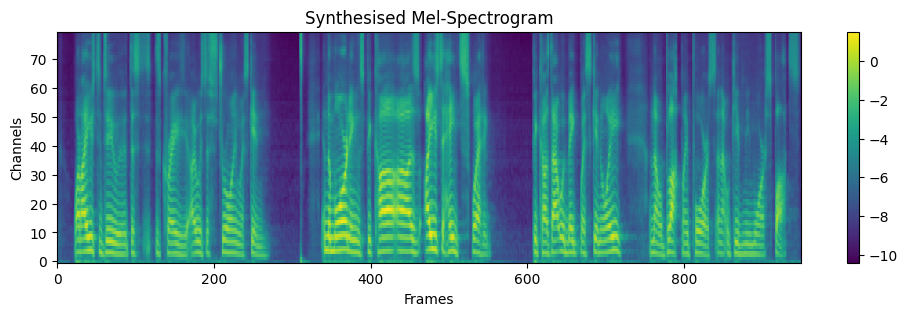

Global seed set to 7277


tensor([[[ 6.,  1.,  5., 13., 16.,  3.,  2.,  5.,  1.,  1.,  1.,  1.,  2.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  4.,  1.,
           2.,  1.,  2.,  1.,  3.,  3.,  5.,  5.,  2.,  3.,  1.,  2.,  2.,  1.,
           2.,  1.,  1.,  4.,  3.,  1.,  2.,  1.,  2.,  3.,  1.,  4.,  3.,  1.,
           1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           2.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,
           1.,  1.,  2.,  2.,  4.,  7.,  6.,  1.,  2.,  1.,  3.,  2.,  5.,  1.,
           2.,  1.,  2.,  1.,  2.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  2.,  2.,  1.,  1.,  1.,  5.,  2.,  2.,  3.,  3., 15., 25.,
          12.,  4.,  8., 26.,  1.,  1.,  1.,  1.,  1.,  2.,  2.,  2.,  2.,  1.,
           2.,  3.,  1.,  1.,  2.,  1.,  2.,  1.,  3.,  1.,  4.,  1.,  2.,  2.,
           3.,  2.,  2.,  2.,  1.,  2., 

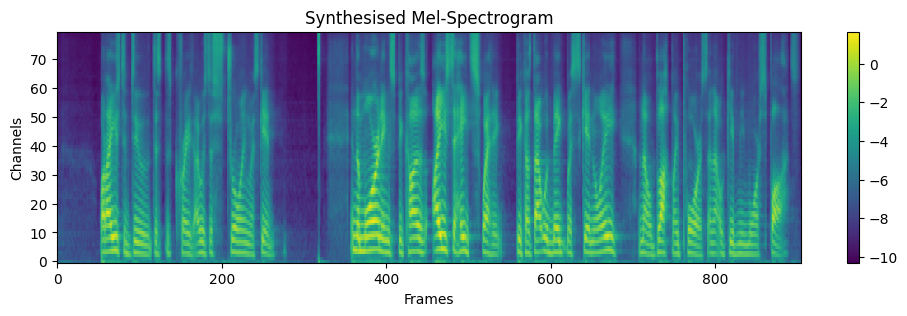

Global seed set to 3959


tensor([[[ 3., 11.,  1.,  1.,  3.,  4.,  4.,  3.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  2.,  1.,  2.,
           1.,  2.,  2.,  1.,  1.,  1.,  2.,  5.,  1.,  2.,  2.,  7.,  8.,  3.,
           2.,  4., 11.,  5.,  1.,  4.,  1.,  1.,  2.,  3.,  3.,  1.,  1.,  3.,
           7.,  3.,  1.,  1.,  1.,  2.,  2.,  1.,  1.,  1.,  4.,  1.,  1.,  1.,
           2.,  3.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  3.,  3.,
           2.,  3.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  2.,  2.,  1.,
           1.,  1.,  2.,  1.,  1.,  3.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  2.,  3.,  4.,  5.,  4.,
           4.,  3.,  5.,  2.,  7., 10.,  1.,  2.,  1.,  2.,  3.,  2., 10.,  1.,
           1.,  4.,  2.,  2.,  3.,  1.,  1.,  2.,  2.,  6.,  4.,  4.,  2.,  1.,
           1.,  2.,  3.,  7., 19.,  9., 

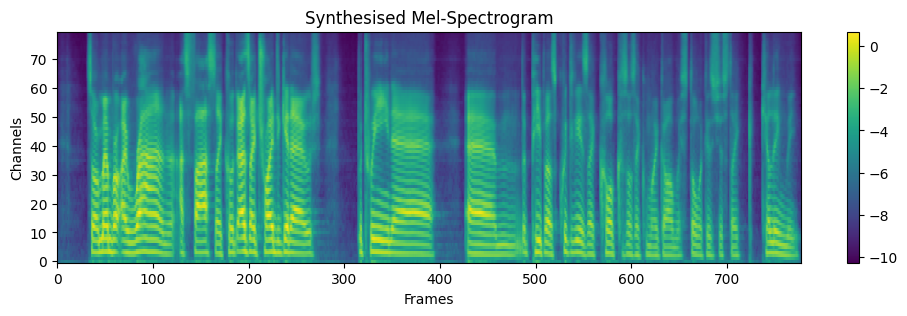

Global seed set to 2505


tensor([[[10.,  1.,  1.,  1.,  6.,  1.,  2., 14.,  1.,  1.,  2.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  2.,  2.,  1.,  3.,
           1.,  2.,  1.,  3.,  1.,  1.,  1.,  5.,  1.,  2.,  1.,  3.,  6., 10.,
           6.,  3.,  4.,  3.,  2.,  7.,  2.,  2.,  4.,  3.,  3.,  1.,  1.,  2.,
           6.,  2.,  2.,  1.,  1.,  3.,  2.,  1.,  1.,  1.,  3.,  1.,  2.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 13.,  2., 12.,  4.,
           2.,  3.,  1.,  2.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,
           1.,  2.,  1.,  1.,  1.,  2.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  2.,
           1.,  1.,  1.,  1.,  1.,  3.,  2.,  1.,  1.,  3.,  2.,  3.,  3.,  4.,
           4.,  1., 10.,  2.,  3.,  8.,  1.,  5.,  6.,  3.,  4.,  6.,  7.,  1.,
           1.,  5.,  2.,  1.,  2.,  1.,  2.,  2.,  3.,  2.,  2.,  3.,  2.,  1.,
           1.,  1.,  4.,  3.,  7.,  7., 

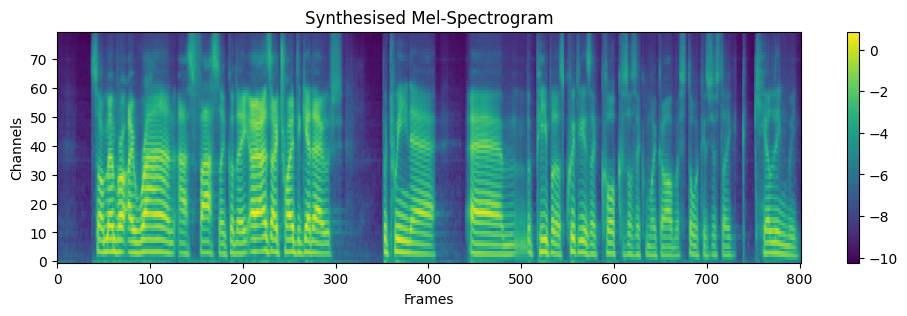

Global seed set to 4942


tensor([[[ 3.,  1.,  3., 10.,  3.,  6.,  3.,  4.,  1.,  1.,  2.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  2.,
           1.,  3.,  3.,  1.,  3.,  1.,  3.,  3.,  1.,  2.,  2.,  3.,  6.,  5.,
           2.,  2.,  5.,  5.,  1.,  2.,  1.,  1.,  2.,  1.,  3.,  1.,  1.,  3.,
           4.,  3.,  1.,  1.,  2.,  4.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  3.,
           1.,  4.,  2.,  1.,  2.,  1.,  1.,  1.,  5.,  1.,  8.,  3.,  4.,  6.,
           2.,  4.,  1.,  2.,  2.,  2.,  2.,  1.,  1.,  1.,  1.,  2.,  3.,  1.,
           1.,  1.,  1.,  2.,  1.,  2.,  1.,  1.,  1.,  2.,  1.,  1.,  2.,  1.,
           1.,  1.,  1.,  1.,  2.,  2.,  1.,  1.,  1.,  1.,  2.,  2.,  3.,  3.,
           5.,  2.,  8.,  2.,  8.,  2.,  3.,  5.,  1.,  3.,  3.,  4.,  2.,  1.,
           1.,  4.,  2.,  2.,  3.,  1.,  5.,  1.,  3.,  4.,  5.,  4.,  3.,  3.,
           2.,  2.,  4.,  4.,  5., 11., 

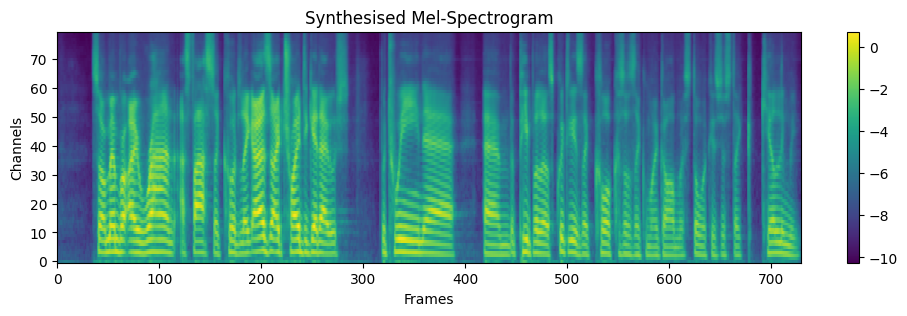

Global seed set to 195


tensor([[[ 5.,  7.,  1.,  1., 13.,  4.,  1.,  3.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  4.,  1.,
           1.,  2.,  2.,  1.,  1.,  1.,  4.,  2.,  1.,  2.,  4.,  7.,  6.,  7.,
           3.,  3.,  2.,  2.,  2.,  2.,  1.,  2.,  3.,  7.,  5.,  1.,  1.,  1.,
           4.,  5.,  3.,  1.,  2.,  3.,  1.,  1.,  2.,  2.,  4.,  2.,  2.,  1.,
           1.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  2.,  2.,  1.,  7.,  4.,
           3.,  2.,  1.,  2.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  2.,  1.,
           1.,  1.,  2.,  2.,  2.,  4.,  1.,  2.,  1.,  1.,  1.,  1.,  2.,  1.,
           1.,  1.,  1.,  1.,  2.,  2.,  2.,  1.,  1.,  3.,  1.,  3.,  3.,  2.,
           3.,  2.,  3.,  1.,  8.,  1.,  7.,  4.,  2.,  4.,  7.,  4.,  4.,  1.,
           1.,  6.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  3.,  4.,  4.,  1.,  1.,
           1.,  2.,  5.,  4.,  8., 12., 

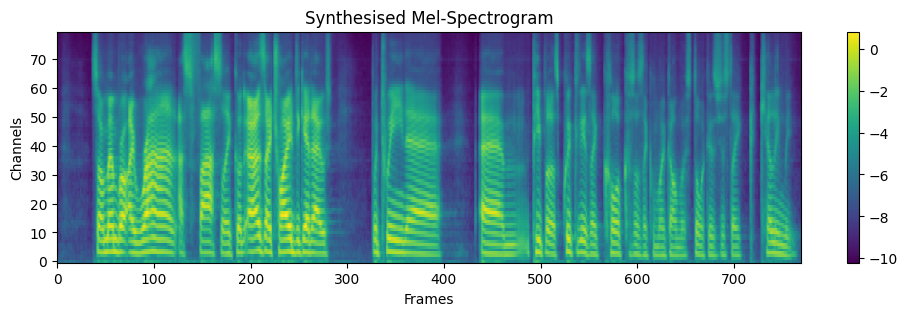

Global seed set to 9757


tensor([[[ 3.,  2.,  1.,  3.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,
           2.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,
           1.,  2.,  2.,  2.,  1.,  1.,  2.,  1.,  3.,  2.,  1.,  1.,  1.,  1.,
           1.,  3.,  2.,  1.,  1.,  3.,  2.,  2.,  2.,  2.,  4., 17.,  5.,  4.,
           1.,  4.,  1.,  1.,  1.,  2.,  2.,  1.,  2.,  1.,  1.,  1.,  2.,  2.,
           3.,  1.,  1.,  2.,  1.,  2.,  1.,  2.,  1.,  1.,  1.,  2.,  2.,  2.,
           1.,  1.,  3.,  1.,  2.,  2.,  3.,  2.,  2.,  3.,  1.,  1.,  2.,  8.,
           1.,  1.,  2.,  2.,  1.,  1.,  3.,  1.,  1.,  1.,  3.,  1.,  2.,  1.,
           3.,  2.,  1.,  1.,  1.,  1.,  2.,  1.,  1., 10.,  1.,  1.,  1.,  1.,
           1.,  3.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  2.,  2.,  5.,  1.,  2.,  2.,  4.,  1.,  3.,  1.,  1.,  2.,
           1.,  1.,  2.,  1.,  1.,  3.,  3.,  3.,  1.,  1.,  2.,  1.,  1.,  1.,
           2.,  1.,  1.,  1.,  1.,  1., 

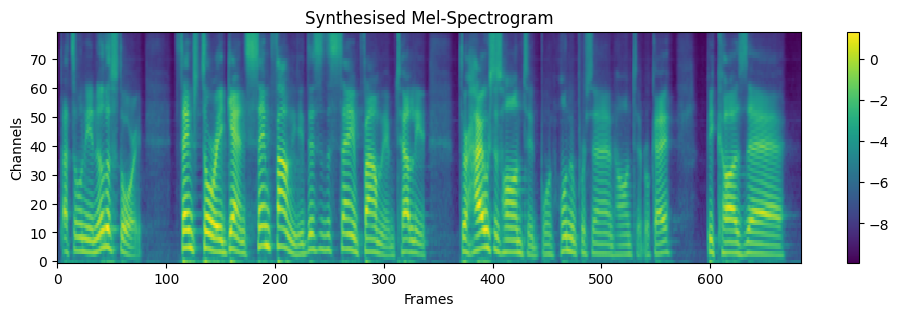

Global seed set to 795


tensor([[[ 2.,  1.,  1.,  3.,  1.,  1.,  1.,  2.,  1.,  1.,  3.,  2.,  1.,  2.,
           1.,  2.,  1.,  1.,  1.,  3.,  1.,  2.,  1.,  2.,  1.,  1.,  1.,  1.,
           1.,  3.,  2.,  3.,  1.,  3.,  1.,  1.,  2.,  2.,  1.,  1.,  6.,  1.,
           2.,  3.,  2.,  1.,  2.,  2.,  3.,  1.,  1.,  1.,  5., 15.,  3.,  7.,
           1.,  8.,  1.,  1.,  1.,  2.,  1.,  1.,  2.,  2.,  1.,  1.,  1.,  1.,
           2.,  2.,  1.,  1.,  2.,  2.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,
           1.,  1.,  3.,  1.,  2.,  2.,  4.,  3.,  2.,  4.,  2.,  2.,  1.,  6.,
           1.,  1.,  2.,  2.,  2.,  1.,  2.,  2.,  1.,  3.,  2.,  1.,  1.,  2.,
           2.,  3.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  5.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,
           2.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  3.,  2.,  2.,  1.,  1.,  1.,
           1.,  1.,  3.,  1.,  1.,  1.,  3.,  2.,  1.,  2.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  1.,  1., 

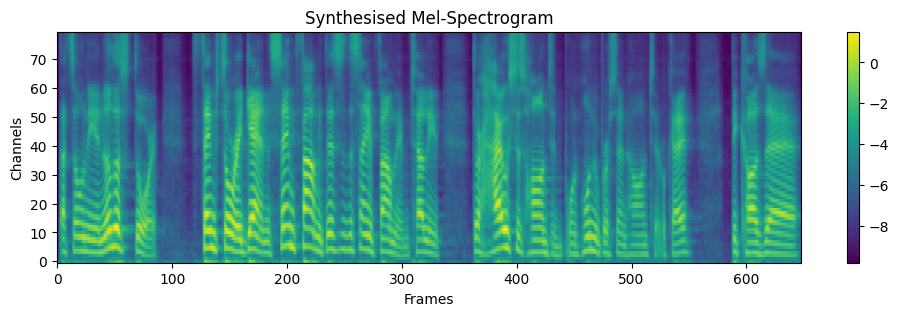

Global seed set to 6567


tensor([[[ 1.,  1.,  1.,  3.,  2.,  1.,  1.,  3.,  1.,  1.,  1.,  1.,  1.,  1.,
           2.,  1.,  2.,  2.,  1.,  1.,  3.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,
           1.,  2.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  2.,  2.,  1.,  1.,  1.,
           1.,  1.,  2.,  3.,  2.,  1.,  2.,  3.,  1.,  2.,  7., 13.,  9.,  3.,
           1.,  1.,  2.,  1.,  1.,  2.,  5.,  1.,  2.,  3.,  1.,  1.,  2.,  2.,
           2.,  1.,  1.,  1.,  2.,  3.,  3.,  2.,  1.,  3.,  1.,  2.,  2.,  1.,
           1.,  1.,  1.,  2.,  3.,  2.,  4.,  2.,  2.,  1.,  1.,  1.,  2.,  3.,
           1.,  1.,  3.,  2.,  2.,  1.,  2.,  2.,  1.,  1.,  3.,  1.,  2.,  1.,
           2.,  2.,  1.,  3.,  1.,  3.,  1.,  1.,  1.,  1.,  2.,  3.,  1.,  1.,
           1.,  3.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  2.,  2.,  3.,  2.,  1.,  1.,  3.,  2.,  1.,  1.,  1.,  1.,  2.,
           1.,  1.,  1.,  1.,  1.,  2.,  3.,  2.,  2.,  1.,  1.,  1.,  1.,  1.,
           1.,  2.,  1.,  1.,  1.,  1., 

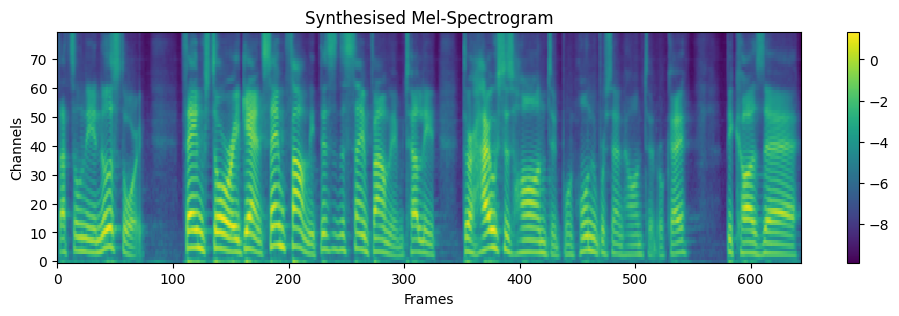

Global seed set to 3807


tensor([[[ 6.,  1.,  1.,  2.,  1.,  1.,  1.,  3.,  1.,  1.,  1.,  1.,  1.,  2.,
           1.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,
           1.,  2.,  3.,  3.,  2.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,
           1.,  2.,  3.,  3.,  2.,  2.,  2.,  2.,  1.,  3.,  7.,  9.,  4.,  7.,
           3.,  6.,  1.,  1.,  1.,  2.,  3.,  2.,  1.,  2.,  1.,  1.,  2.,  1.,
           3.,  1.,  1.,  1.,  1.,  2.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  2.,  2.,  2.,  3.,  8.,  2.,  3.,  2.,  2.,  1.,  2.,  2.,  3.,
           1.,  1.,  1.,  2.,  1.,  1.,  2.,  2.,  1.,  2.,  3.,  1.,  2.,  3.,
           1.,  1.,  2.,  2.,  1.,  3.,  1.,  1.,  4.,  1.,  1.,  4.,  1.,  1.,
           1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  4.,  1.,  1.,  2.,  3.,  2.,  2.,  2.,  1.,  4.,
           1.,  1.,  2.,  1.,  1.,  2.,  1.,  2.,  1.,  2.,  2.,  1.,  1.,  2.,
           1.,  1.,  1.,  1.,  1.,  1., 

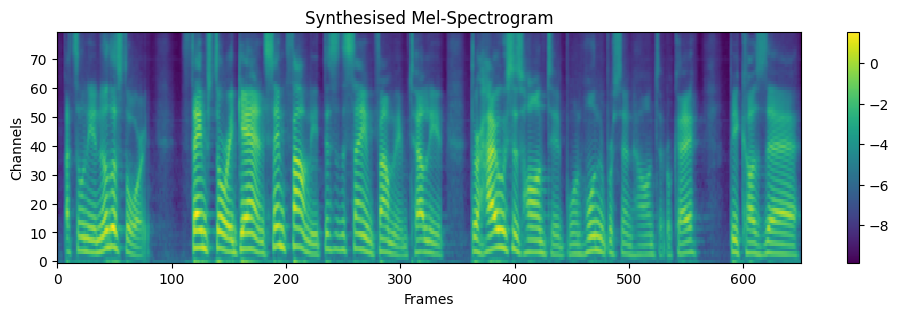

Number of ODE steps: 10
Mean RTF:				0.020956 ± 0.003944
Mean RTF Waveform (incl. vocoder):	0.031546 ± 0.007028


In [32]:
outputs, rtfs = [], []
rtfs_w = []
for i, text in enumerate(tqdm(texts)):
    seed_everything(random.randint(1, 10000))
    output = synthesise(text) #, torch.tensor([15], device=device, dtype=torch.long).unsqueeze(0))
    output['waveform'] = to_waveform(output['mel'], vocoder)

    # Compute Real Time Factor (RTF) with HiFi-GAN
    t = (dt.datetime.now() - output['start_t']).total_seconds()
    rtf_w = t * 22050 / (output['waveform'].shape[-1])

    ## Pretty print
    print(f"{'*' * 53}")
    print(f"Input text - {i}")
    print(f"{'-' * 53}")
    print(output['x_orig'])
    print(f"{'*' * 53}")
    print(f"Phonetised text - {i}")
    print(f"{'-' * 53}")
    print(output['x_phones'])
    print(f"{'*' * 53}")
    print(f"RTF:\t\t{output['rtf']:.6f}")
    print(f"RTF Waveform:\t{rtf_w:.6f}")
    rtfs.append(output['rtf'])
    rtfs_w.append(rtf_w)

    ## Display the synthesised waveform
    plot_spectrogram(output['mel'])
    ipd.display(ipd.Audio(output['waveform'], rate=22050))

    ## Save the generated waveform
    save_to_folder(i, output, OUTPUT_FOLDER)

print(f"Number of ODE steps: {n_timesteps}")
print(f"Mean RTF:\t\t\t\t{np.mean(rtfs):.6f} ± {np.std(rtfs):.6f}")
print(f"Mean RTF Waveform (incl. vocoder):\t{np.mean(rtfs_w):.6f} ± {np.std(rtfs_w):.6f}")

In [20]:
a1 = np.load('/home/smehta/Projects/Matcha-TTS/synth_output/0.npy')
a2 = np.load('/home/smehta/Projects/Matcha-TTS/synth_output/1.npy')